In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import seaborn as sns
import math

from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

from scipy.sparse import issparse

import gc

sc.settings.set_figure_params(
    dpi=300,           
    frameon=False,     
    #figsize=(6, 5),    
    fontsize=16,       
    #format='pdf'     
)

## FOR STANDARD NORMALIZATION

Done with all the experiments mixed in order to observe the joint UMAP

In [2]:
# --- LOAD DATA ---
adata = sc.read_h5ad("../data/data_standard_norm_mixed.h5ad")

## ELBOW PLOT

We look for the critical point in the elbow plot in order to infer the correct number of PC to use

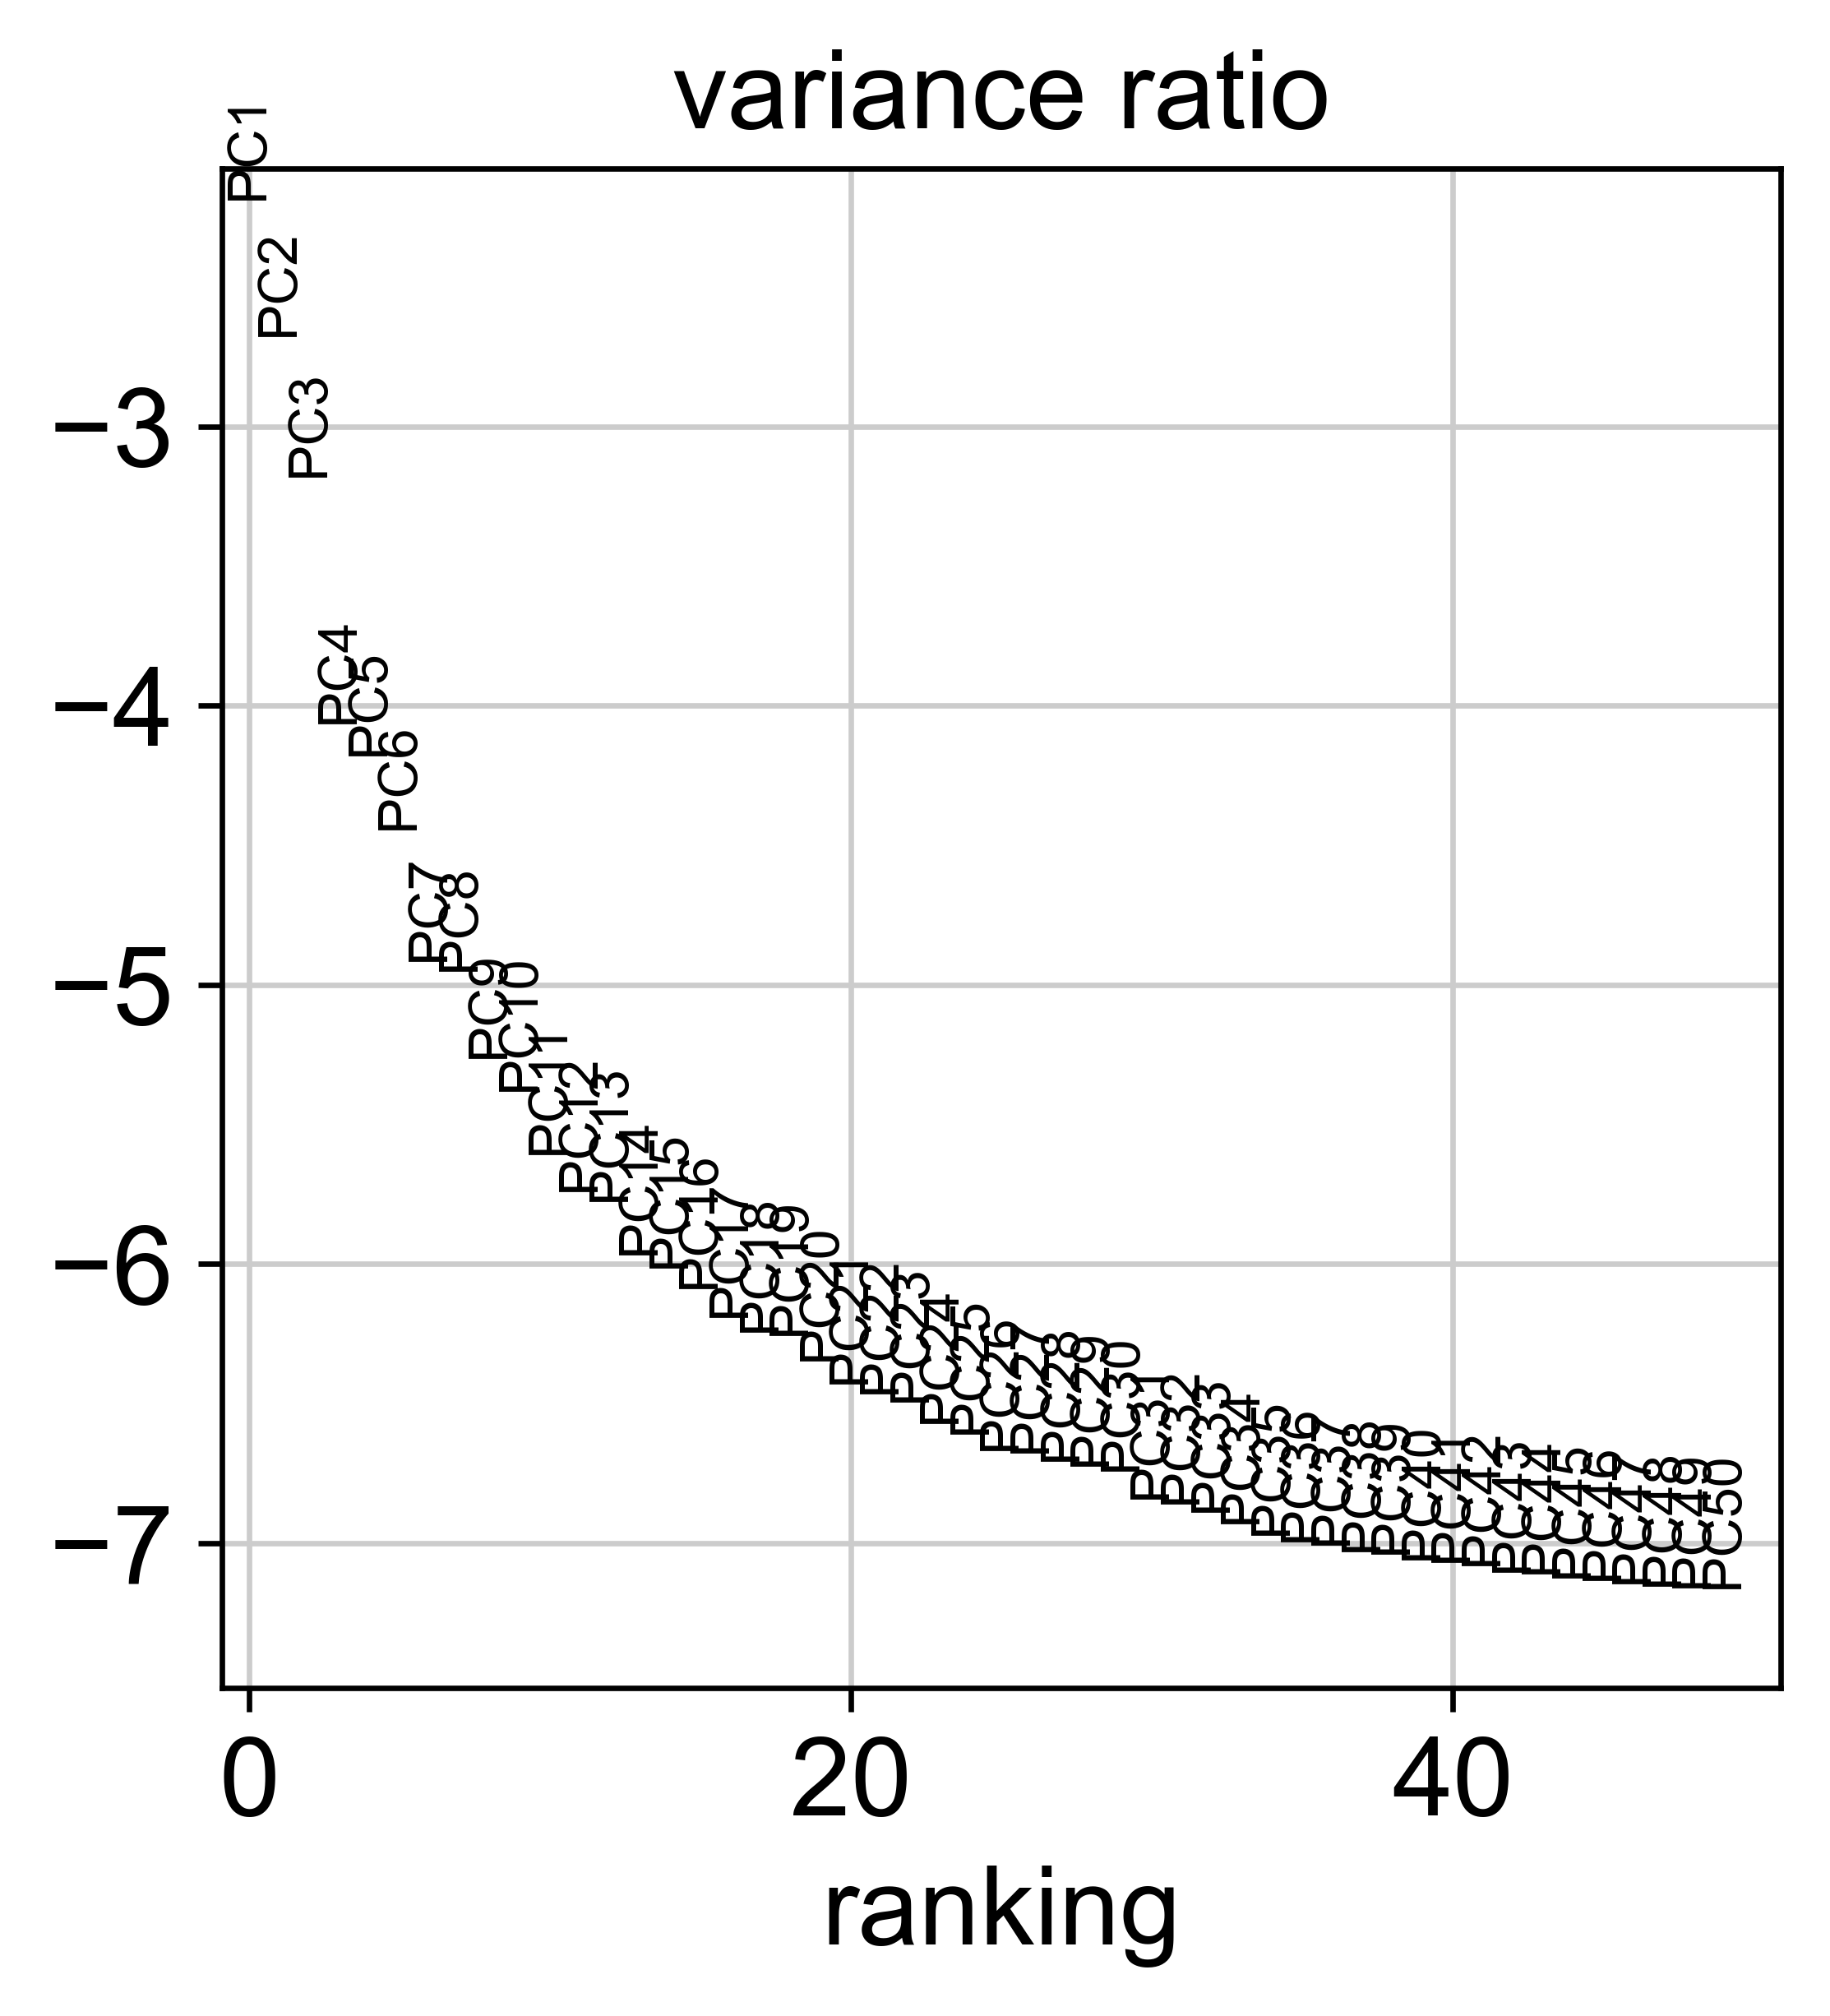

In [3]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# --- PCA for 50 components to map the tail ---
sc.tl.pca(adata, svd_solver='arpack', n_comps=50) 

# --- ELBOW PLOT (Visual Inspection) ---
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

Analytical detection of the tipping point: furthest point of the data of an imaginary line traced between the minimum and maximum value in the variance for different PC number.

Analytical Elbow Point (Knee): 7 PCs


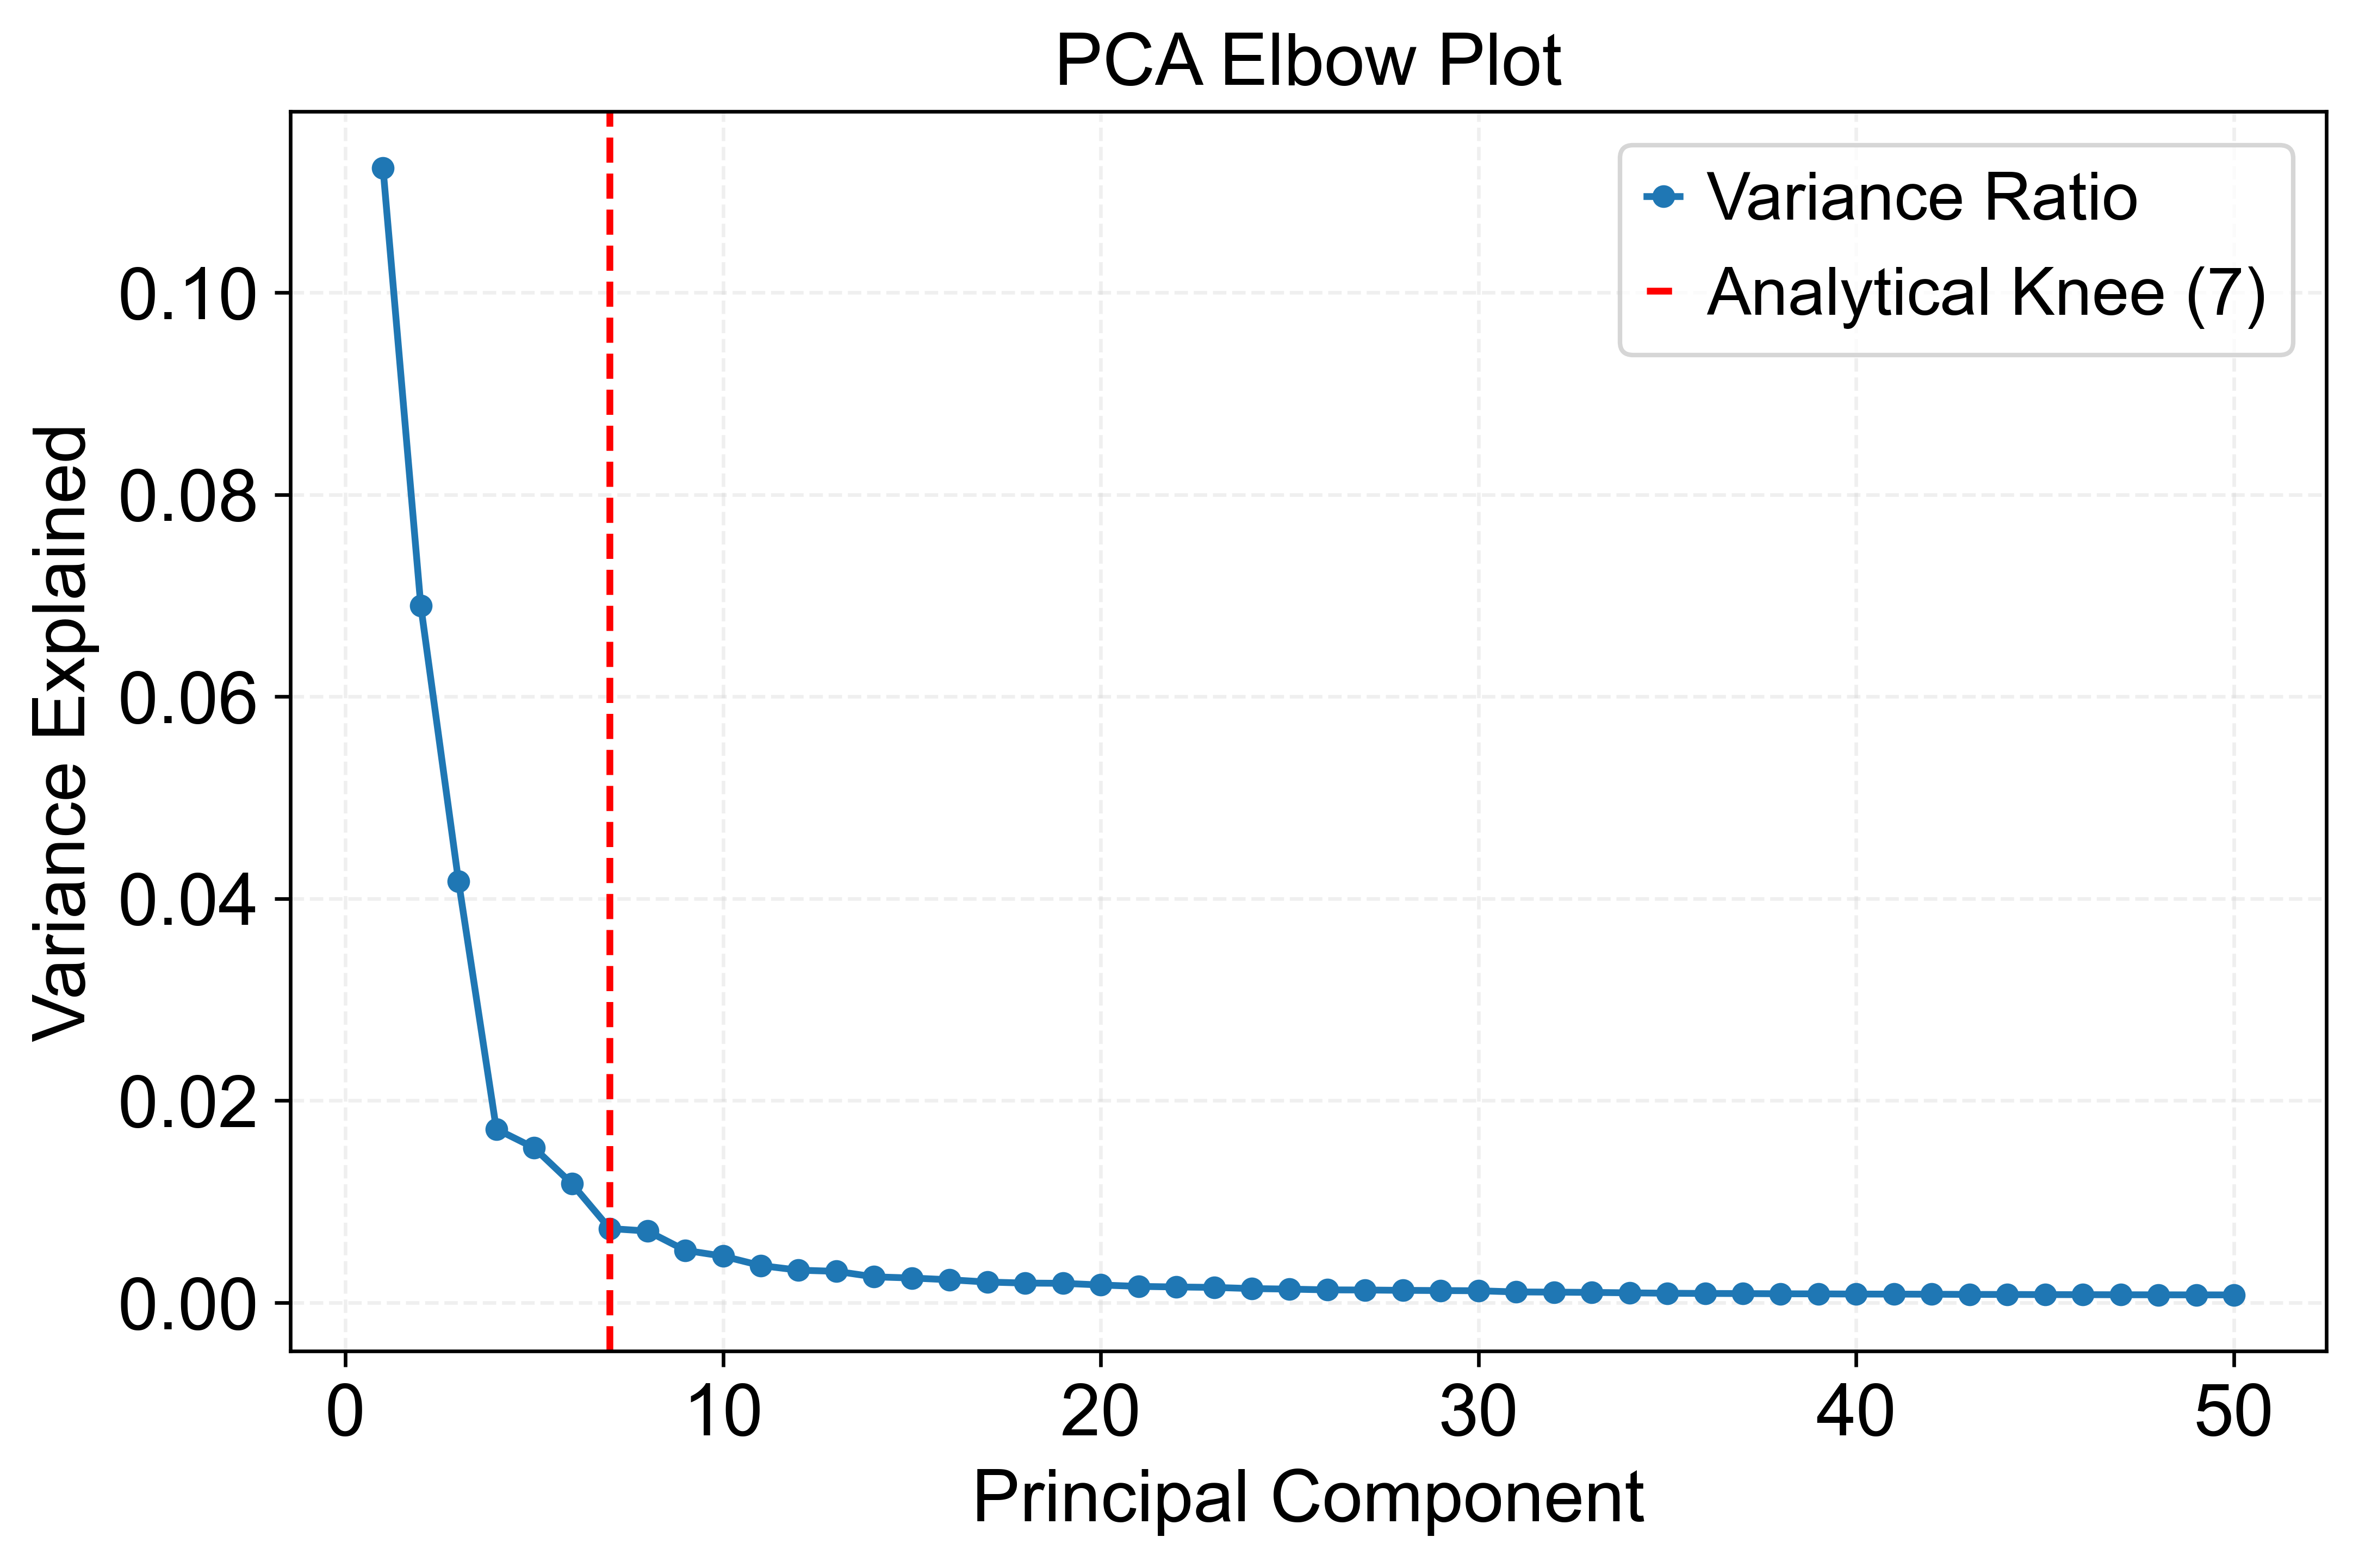

In [4]:
def find_optimal_pcs_analytical(adata, n_pcs_total=50):
    """
    Finds the Knee point of the PCA variance ratio curve geometrically.
    """
    # Get variance ratio (eigenvalues normalized)
    variance_ratio = adata.uns['pca']['variance_ratio']
    
    # x and y coordinates (normalized to 0-1 range for geometry)
    x = np.arange(len(variance_ratio))
    y = variance_ratio
    
    # Normalize to unit square to treat x and y equally
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    
    # Coordinates of the line connecting start (P1) and end (P2)
    # Line equation: Ax + By + C = 0
    # Vector P1->P2 = (x2-x1, y2-y1)
    # Normal vector = (y1-y2, x2-x1)
    
    P1 = np.array([x_norm[0], y_norm[0]])
    P2 = np.array([x_norm[-1], y_norm[-1]])
    
    # Distance from each point to the line defined by P1 and P2
    # d = |(x2-x1)(y1-y0) - (x1-x0)(y2-y1)| / sqrt((x2-x1)^2 + (y2-y1)^2)
    # Here P0 is the point on the curve (x_norm[i], y_norm[i])
    
    numerator = np.abs((P2[0]-P1[0])*(P1[1]-y_norm) - (P1[0]-x_norm)*(P2[1]-P1[1]))
    denominator = np.sqrt((P2[0]-P1[0])**2 + (P2[1]-P1[1])**2)
    
    distances = numerator / denominator
    
    # The knee is the point with max distance
    knee_index = np.argmax(distances)
    
    return knee_index + 1 # +1 because indices start at 0

# --- EXECUTE ---
optimal_pc_analytical = find_optimal_pcs_analytical(adata)
print(f"Analytical Elbow Point (Knee): {optimal_pc_analytical} PCs")

# --- PLOT WITH KNEE ---
var_ratio = adata.uns['pca']['variance_ratio']
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), var_ratio, 'o-', markersize=4, label='Variance Ratio')
plt.axvline(optimal_pc_analytical, color='r', linestyle='--', label=f'Analytical Knee ({optimal_pc_analytical})')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('PCA Elbow Plot')
plt.legend()
plt.grid(True, ls='--', alpha=0.3)
plt.show()

## PCA / UMAP configuration

INTERPRETATION:

1. In the 'plate' coloring, mESC cluster is a mix of colors => ok
2. Distinct islands of "Plate 1 mESC" and "Plate 2 mESC" => batch correction needed (e.g., Harmony, BBKNN, scVI).

In [5]:
# --- UMAP ---

# we use the analytical knee + 10 PCs to ensure we capture enough variance
n_pcs_used = optimal_pc_analytical + 10 

print(f"Using {n_pcs_used} PCs for neighborhood graph.")

sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=n_pcs_used)
sc.tl.umap(adata, random_state=12) 

Using 17 PCs for neighborhood graph.


## VISUALIZATION

Batch effects

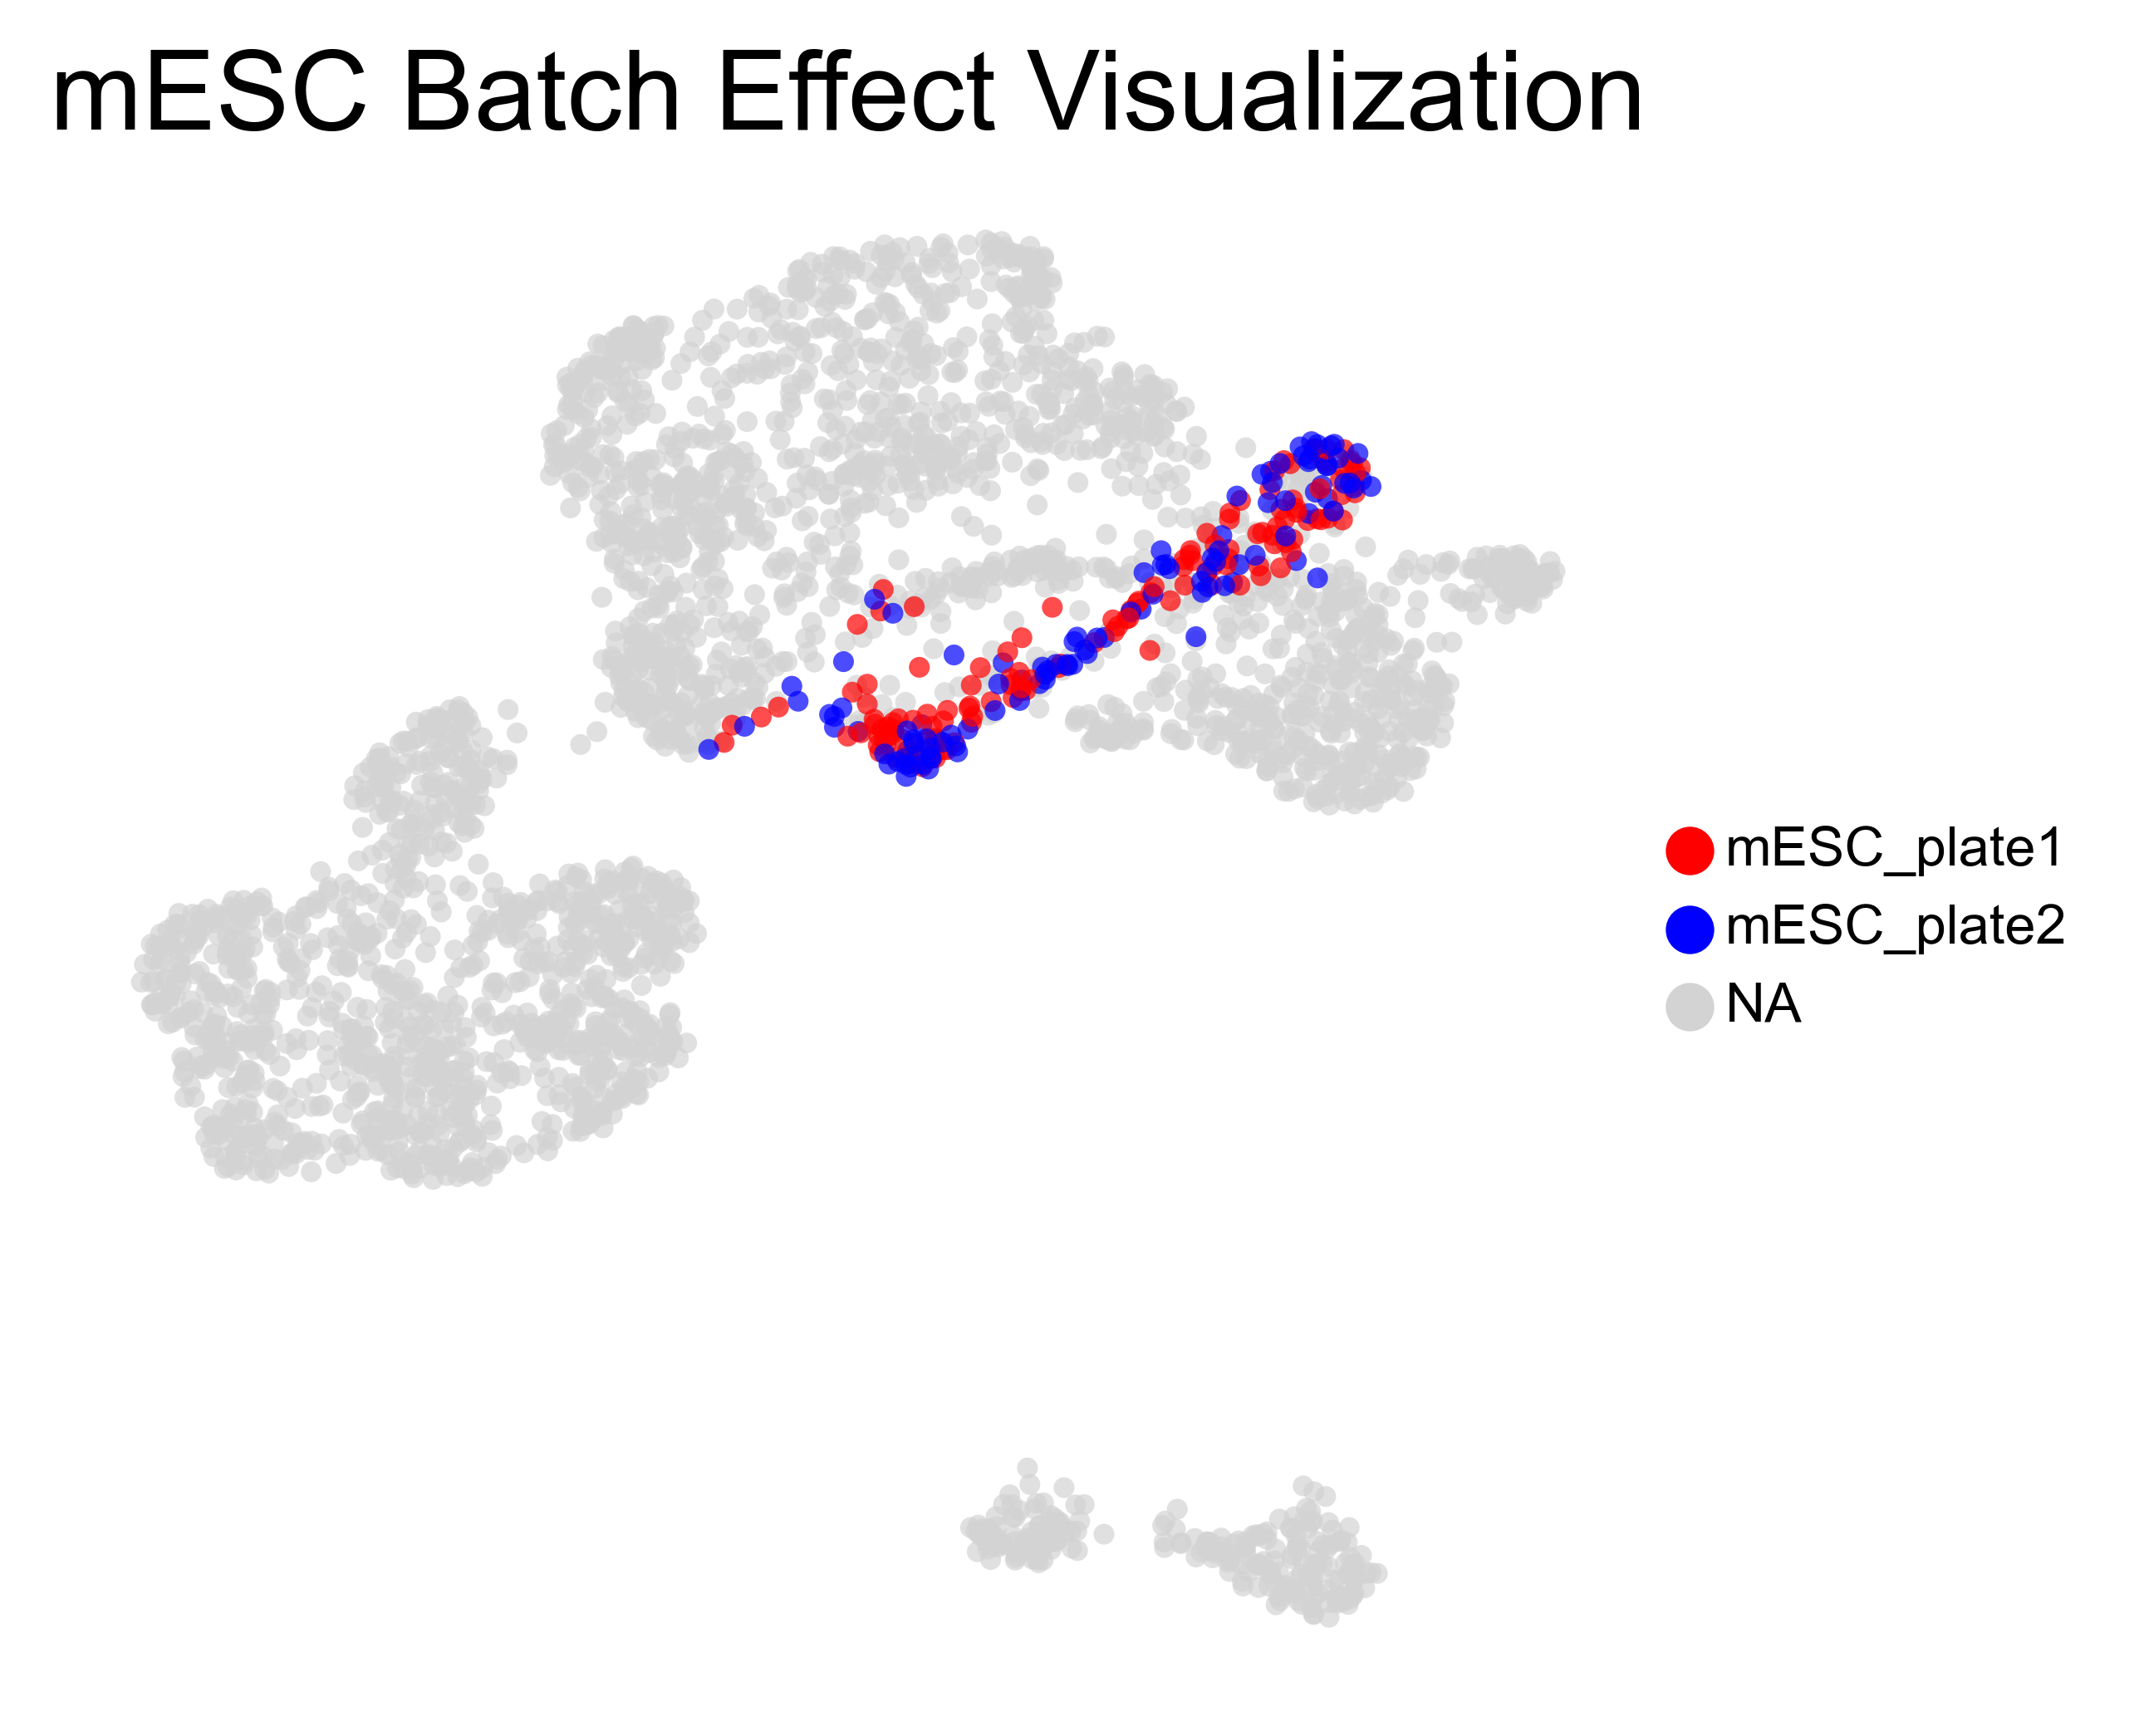

In [6]:
# Plot UMAP colored by batch to visualize batch effects
sc.pl.umap(
    adata, 
    color=['batch_check'], 
    palette=['red', 'blue', 'green', 'orange', 'purple','lightgrey'],
    alpha=0.7,
    legend_fontsize=8,   
    #legend_loc='',           
    title='mESC Batch Effect Visualization',          
    #groups=['mESC_plate1', 'mESC_plate2', 'mESC_plate3', 'mESC_plate4','mESC_plate5'],
)

General

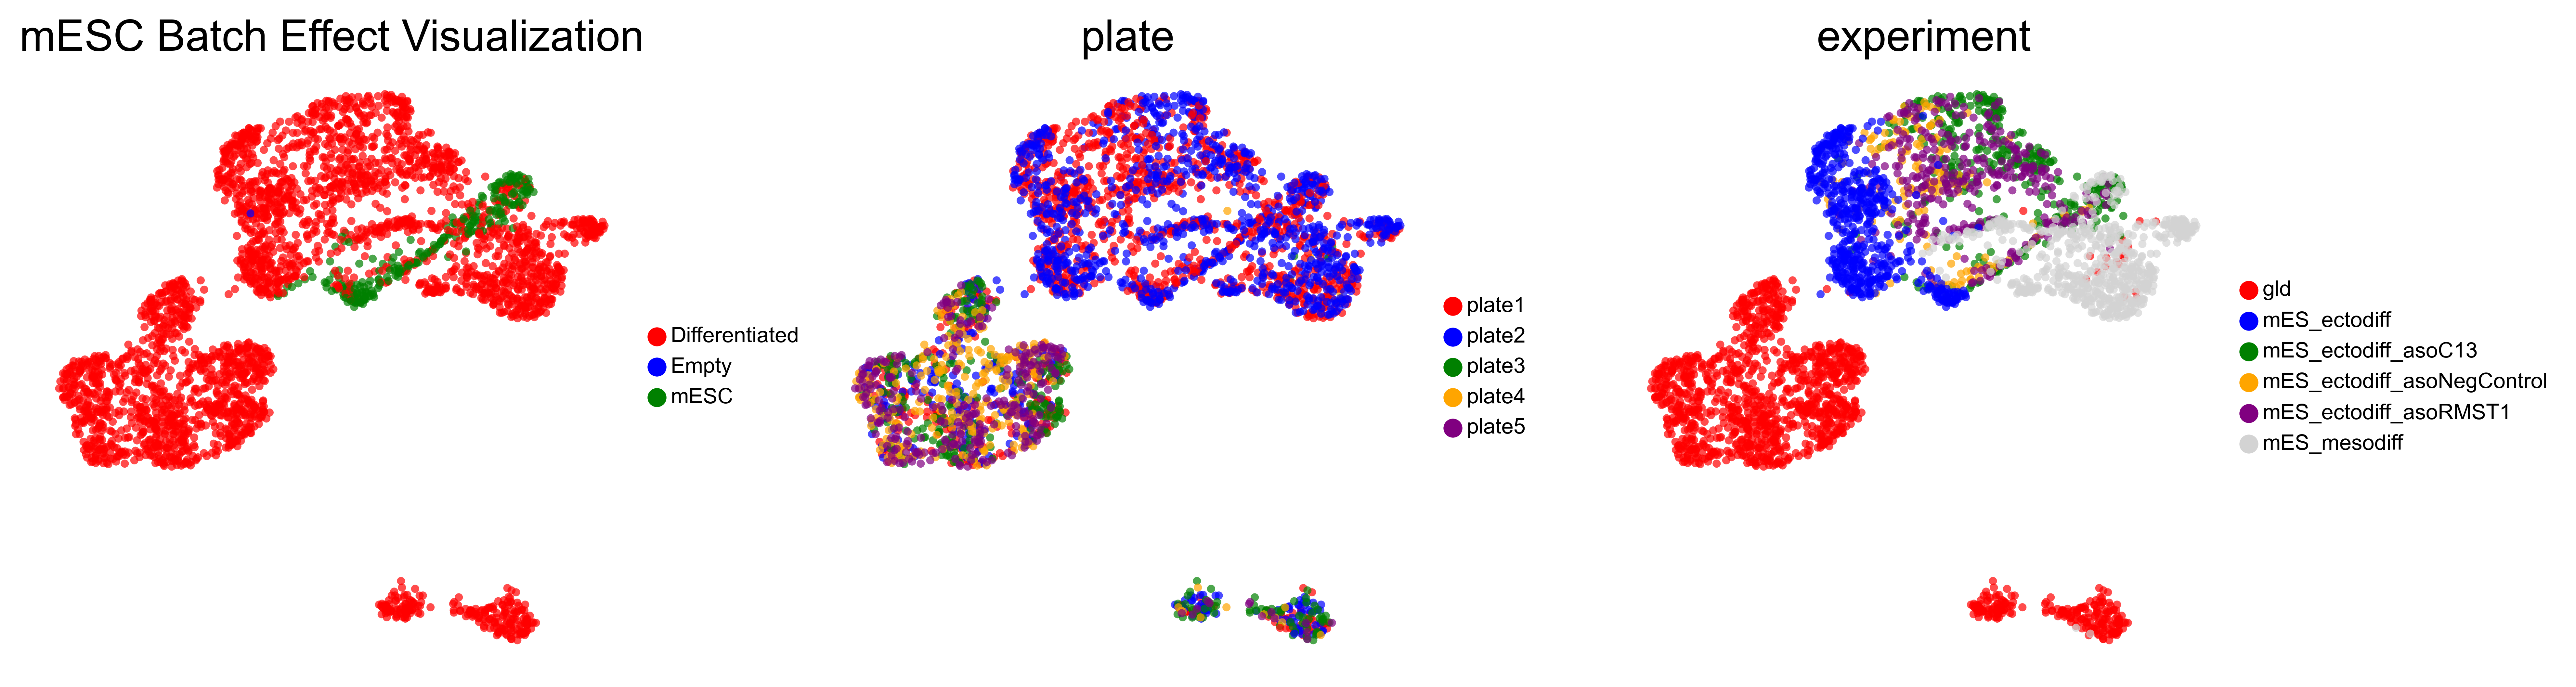

In [7]:
# Plot
sc.pl.umap(
    adata, 
    color=['sample_type', 'plate', 'experiment'], 
    palette=['red', 'blue', 'green', 'orange', 'purple','lightgrey'],
    alpha=0.7,
    legend_fontsize=8,   
    #legend_loc='',           
    title='mESC Batch Effect Visualization',          
    #groups=['mESC_plate1', 'mESC_plate2', 'mESC_plate3', 'mESC_plate4','mESC_plate5'],
)

Genes related to different cell types

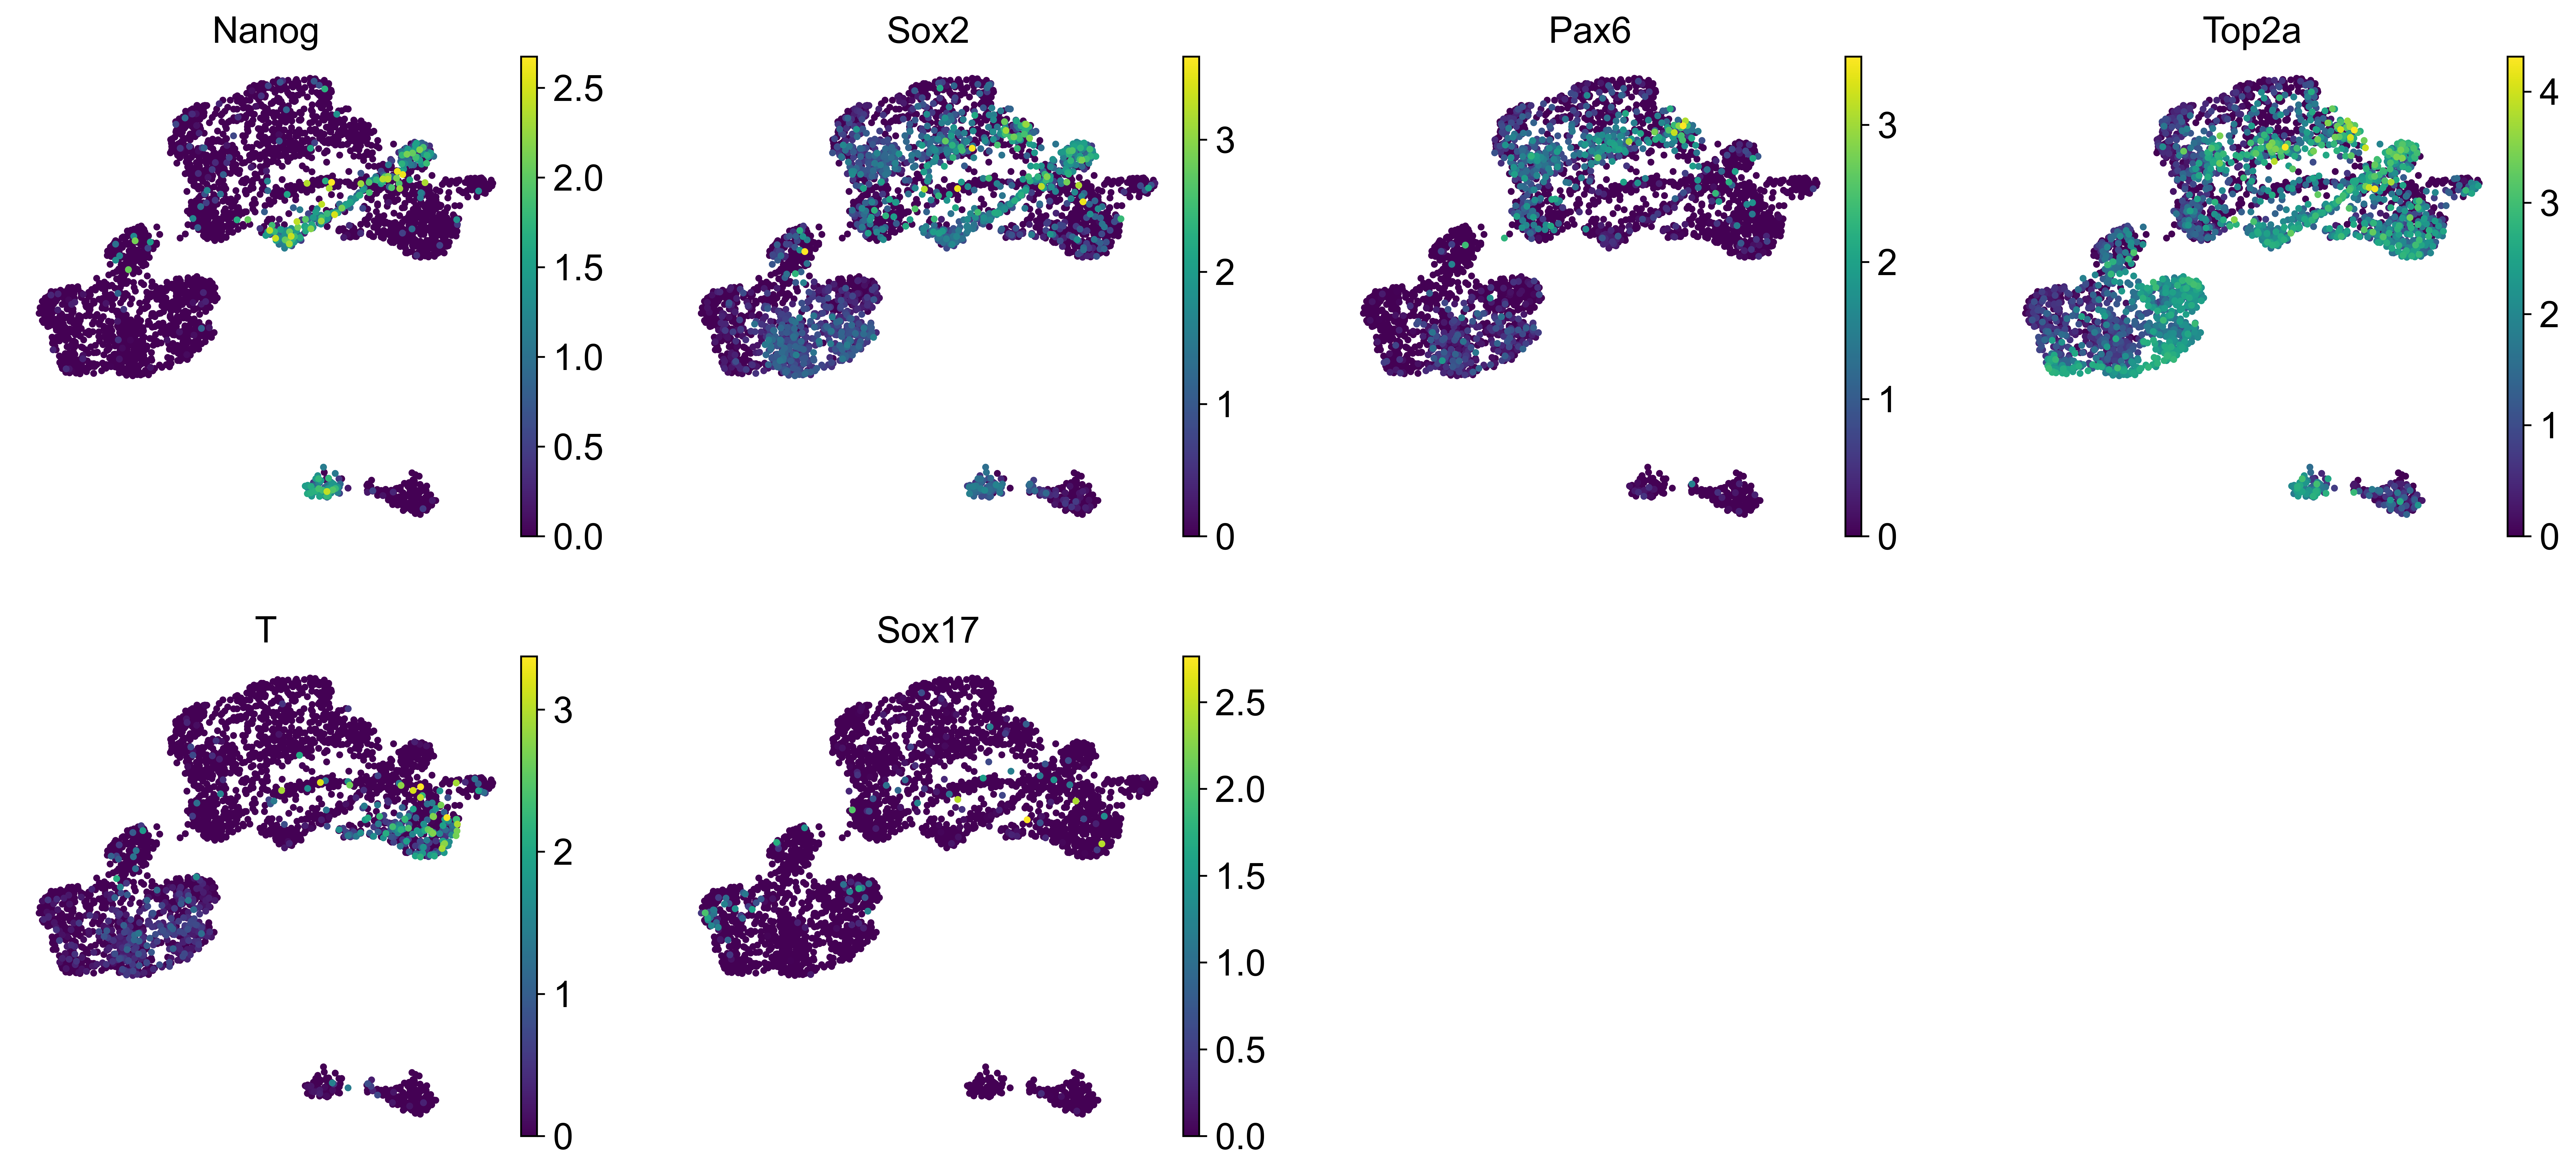

In [8]:
sc.pl.umap(adata, color = ['Nanog','Sox2','Pax6','Top2a','T','Sox17'])